# **Laboratorio 1.6, Física computacional 1**

Juan Esteban Garces Duran

C.C 1077225154

In [40]:
import numpy as np
import numpy.linalg as la
from scipy import integrate
import matplotlib.pyplot as plt

# **Exercise 1: solve the EDO**

Use FEM to solve the next EDO (use the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
\dfrac{d^2y}{dx^2}=-xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(2-x)-x
\end{equation}

In [41]:
N=20                  #Número de nodos internos, no se incluyen las fronteras.
a=0                   #Solucionaremos para el intervalo [0,1]
b_dom=1

#Nodos totales, 20 internos y las fronteras.
x_nodes=np.linspace(a,b_dom,N+2)

#Tamaño de los elementos sobre los que resolvemos la ecuación.
h=x_nodes[1]-x_nodes[0]


#Ingresamos las condiciones de frontera del sistema.
Ua=3-np.exp(1)    #Solución en x=0
Ub=0              #Solución en x=1


#Generamos la matriz de rigidez
A=np.zeros((N,N))

for i in range(N):                 #De manera analitica, teniendo en cuenta que para cada elemento h_i tiene el mismo valor h,
  A[i,i]=2/h                       #tenemos que en la diagonal toma el valor de 2/h y en los valores vecinos de la diagonal
  if i>0:                          #toma el valor de -1/h.
    A[i,i-1]=-1/h
  if i < N-1:
    A[i,i+1]=-1/h


#Definimos ahora la función que inhomogeneiza la ecuación diferencial.
def f(x):
  return x*np.exp(x)


#Definimos el vector B, donde para simplificar el problema vamos a usar la aproximacción b_i≈h*f(x_i)
#Esta aproximación se tiene al suponer que en el elemento se cumple que f(x)≈f(x_i), de tal forma que la integral se simplifica.

b=np.zeros(N)

for i in range(N):
  #nodo correspondiente
  xi=x_nodes[i+1]
  b[i]=h*f(xi)


#Añadimos las condiciones de frontera al vector B.
b[0]+=Ua/h
b[-1]+=Ub/h


#Resolvemos el sistema.
u_internal=la.solve(A,b)


#Reconstruimos la solución agregando las fronteras ya conocidas.
u=np.concatenate(([Ua],u_internal,[Ub]))

#Definimos la solución analitica.
x=x_nodes
u_exact=1-np.exp(1)+np.exp(x)*(2-x)-x


#Calculamos la norma del error entre la solución numerica y la solución analitica.
error=np.linalg.norm(u-u_exact)
print("Error =", error)

Error = 0.00034117969050891144


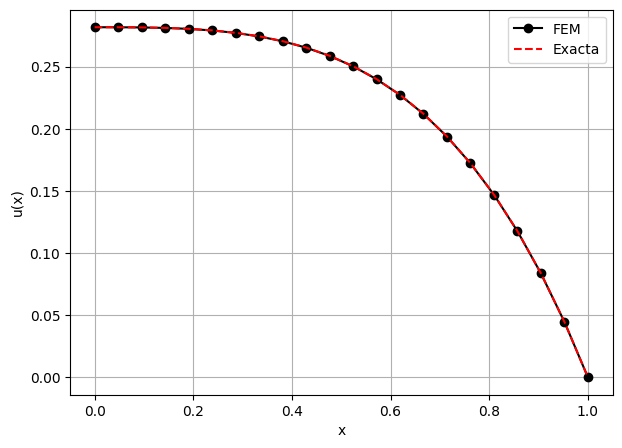

In [42]:
#Realizamos la grafica.
plt.figure(figsize=(7,5))
plt.plot(x,u,'ko-',label='FEM')
plt.plot(x,u_exact,'r--',label='Exacta')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.grid()
plt.legend()
plt.show()

Vemos que la solución numerica encontrada mediante el metodo de elementos finitos fue bastante preciso, se ajusta perfectamente a la solución exacta del problema, y el error es bastante bajo.

# **Exercise 2: Solve the EDO:**

see pag 36: https://cimec.org.ar/foswiki/pub/Main/Cimec/CursoFEM/cursofem_1.pdf

$-\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,,$
in $0\le x\le 1$, with $U(0)=U(1)=0$.

The exact solution is known $U(x)=\dfrac{1}{\pi^2}\sin(\pi x)$.

In [43]:
#Solucionaremos de nuevo para el dominio [0,1]

N=20            #Vamos a tener 20 nodos y cada elemento tendra un tamaño h.
h=1/(N-1)
x=np.linspace(0,1,N)

#Definimos la matriz de rigidez.
A=np.zeros((N,N))
for i in range(1,N):
  A[i-1,i-1]+=1/h
  A[i-1,i]+=-1/h
  A[i,i-1]+=-1/h
  A[i,i]+=1/h


#Definimos las funciones base.
def lin1(x,x1,x2):
  return (x-x1)/(x2-x1)

def lin2(x,x1,x2):
  return (x2-x)/(x2-x1)


#Se define la función que inhomogeneiza la ecuación diferencial.
def f(x):
  return np.sin(np.pi*x)

#Definimos el vector B.
b=np.zeros(N)

for i in range(1,N):
  x1=x[i-1]
  x2=x[i]

  b[i-1]+=integrate.quad(lambda xx: f(xx)*lin2(xx,x1,x2),x1,x2)[0]

  b[i]+=integrate.quad(lambda xx: f(xx)*lin1(xx,x1,x2),x1,x2)[0]


#Colocamos las condiciones de frontera u(0)=0, u(1)=0
A[0,:]=0
A[:,0]=0
A[0,0]=1
b[0]=0

A[-1,:]=0
A[:,-1]=0
A[-1,-1]=1
b[-1]=0


#Resolvemos el sistema.
U=la.solve(A,b)

#Solución exacta.
U_exact=(1/np.pi**2)*np.sin(np.pi*x)

#Calculamos la norma del error entre la solución numerica y la solución analitica.
error=np.linalg.norm(U-U_exact)
print("Error =", error)

Error = 7.366273342682184e-17


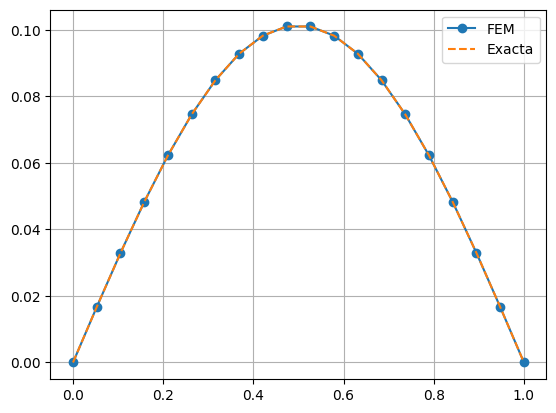

In [44]:
#Graficamos.
plt.plot(x,U,'o-',label='FEM')
plt.plot(x,U_exact,'--',label='Exacta')
plt.legend()
plt.grid()
plt.show()

Vemos que el metodo de elementos finitos tiene una exactitud bastante alta, en esta ocación el error es del orden de 10^-17, bastante bajo.